# Notebook 24: Causality and Fairness

**BINF 4002 — Machine Learning for Health | Lecture 24 Companion**

---

## Overview

This notebook covers two tightly connected topics:

1. **Fairness in health AI** — The impossibility theorem, the Obermeyer et al. (2019) case study, subgroup evaluation, and mitigation strategies.
2. **Causal inference** — DAGs, confounders vs. mediators vs. colliders, propensity score methods, and the causal roots of algorithmic bias.

**Data sources:**
- **MEPS (Medical Expenditure Panel Survey)** via AIF360 — real healthcare utilization data with demographics
- **Obermeyer synthpop** — synthetic data replicating the racial bias in a commercial health algorithm
- **NHEFS (National Health and Nutrition Examination Survey Follow-up Study)** via `causaldata` — real data from Hernan & Robins' *Causal Inference* textbook for collider bias and propensity score demos
- **Simulated data** — for the DAG patterns demo only (requires known causal structure)

All figures save to `figures/` for use in lecture slides.

In [1]:
!pip install -qq aif360 causaldata

/bin/bash: line 1: pip: command not found


In [2]:
## SETUP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, recall_score, precision_score,
                             confusion_matrix, roc_curve)
from sklearn.preprocessing import StandardScaler

os.makedirs("figures", exist_ok=True)

sns.set_style("whitegrid")
PALETTE = sns.color_palette("colorblind")
COL_BLUE = "#1D4F91"
COL_ACCENT = "#D2492A"
COL_GREEN = "#2E8B57"
COL_GRAY = "#757575"

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
})

rng = np.random.default_rng(42)
print("Setup complete.")

ModuleNotFoundError: No module named 'seaborn'

---
## Loading Data: MEPS via AIF360

The **Medical Expenditure Panel Survey** (MEPS) contains real healthcare utilization data
with demographics including race/ethnicity. AIF360 provides it pre-formatted for fairness research.

The prediction task: will this individual have **high healthcare utilization** (>=10 visits)?

In [3]:
import os
import urllib.request
import zipfile
import pandas as pd

# ==============================================================================
# Download and setup MEPS data for AIF360
# ==============================================================================
# AIF360 requires the h181.csv file in its raw data folder.
meps_dir = '/usr/local/lib/python3.12/dist-packages/aif360/data/raw/meps'
os.makedirs(meps_dir, exist_ok=True)
meps_csv = os.path.join(meps_dir, 'h181.csv')

if not os.path.exists(meps_csv):
    print("Downloading MEPS Panel 19 (h181) dataset...")
    zip_url = 'https://meps.ahrq.gov/mepsweb/data_files/pufs/h181ssp.zip'
    zip_path = '/tmp/h181ssp.zip'
    urllib.request.urlretrieve(zip_url, zip_path)

    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/tmp/meps')

    print("Converting SAS transport file to CSV (this may take a minute)...")
    df_sas = pd.read_sas('/tmp/meps/h181.ssp', format='xport', encoding='utf-8')
    df_sas.to_csv(meps_csv, index=False)
    print("MEPS dataset successfully prepared!")

# ==============================================================================
# Load MEPS data via AIF360
# ==============================================================================
from aif360.datasets import MEPSDataset19

# Load the MEPS panel 19
meps = MEPSDataset19()

# Convert to a standard DataFrame for flexibility
df_meps = meps.convert_to_dataframe()[0]

# The protected attribute is RACE (1=White, 0=Non-White)
# The label is UTILIZATION (1=high, 0=low)
print(f"\nMEPS dataset: {df_meps.shape[0]} individuals, {df_meps.shape[1]} features")
print(f"Label (UTILIZATION): {df_meps[meps.label_names[0]].value_counts().to_dict()}")
print(f"Protected (RACE): {df_meps['RACE'].value_counts().to_dict()}")

# Compute prevalence by group
for race_val, race_name in [(1.0, "White"), (0.0, "Non-White")]:
    subset = df_meps[df_meps['RACE'] == race_val]
    prev = subset[meps.label_names[0]].mean()
    print(f"  Prevalence ({race_name}): {prev:.3f} (n={len(subset)})")


PermissionError: [Errno 13] Permission denied: '/usr/local/lib/python3.12/dist-packages/aif360'

In [4]:
# ==============================================================================
# Prepare MEPS for modeling
# ==============================================================================
from sklearn.model_selection import train_test_split

label_col = meps.label_names[0]
protected_col = 'RACE'

feature_cols = [c for c in df_meps.columns if c not in [label_col, protected_col]]

X = df_meps[feature_cols].values
y = df_meps[label_col].values.ravel()
group = df_meps[protected_col].values.ravel()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create train/test splits for honest model evaluation in Figure 1
X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    X_scaled, y, group, test_size=0.3, random_state=42, stratify=y
)

# Create global masks for later threshold adjustment cells
mask_w = group == 1.0
mask_nw = group == 0.0

print(f"Features: {len(feature_cols)}, Samples: {len(y)}")
print(f"Positive rate: {y.mean():.3f}")


NameError: name 'meps' is not defined

---
# Part 1: Causality

Tuesday (L23) introduced confounding and asked "are hazard ratios causal?" Today we
formalize the answer with DAGs, the do-operator, and propensity scores.

---
## Figure 1: A Gallery of Biases

**LECTURE FIGURE**

Each bias students have seen this semester maps to a DAG pattern. Four panels show:
1. **Confounder → Simpson's Paradox:** A confounder creates a spurious aggregate association that reverses within strata.
2. **Collider → Berkson's Paradox:** Conditioning on a common effect creates a spurious negative correlation.
3. **Collider → Healthy Volunteer Effect:** Selection into a study attenuates associations.
4. **Mediator → Overadjustment:** Adjusting for a variable on the causal path blocks the effect you want to measure.

Each panel shows the naive vs correct estimate alongside the DAG structure.

NameError: name 'rng' is not defined

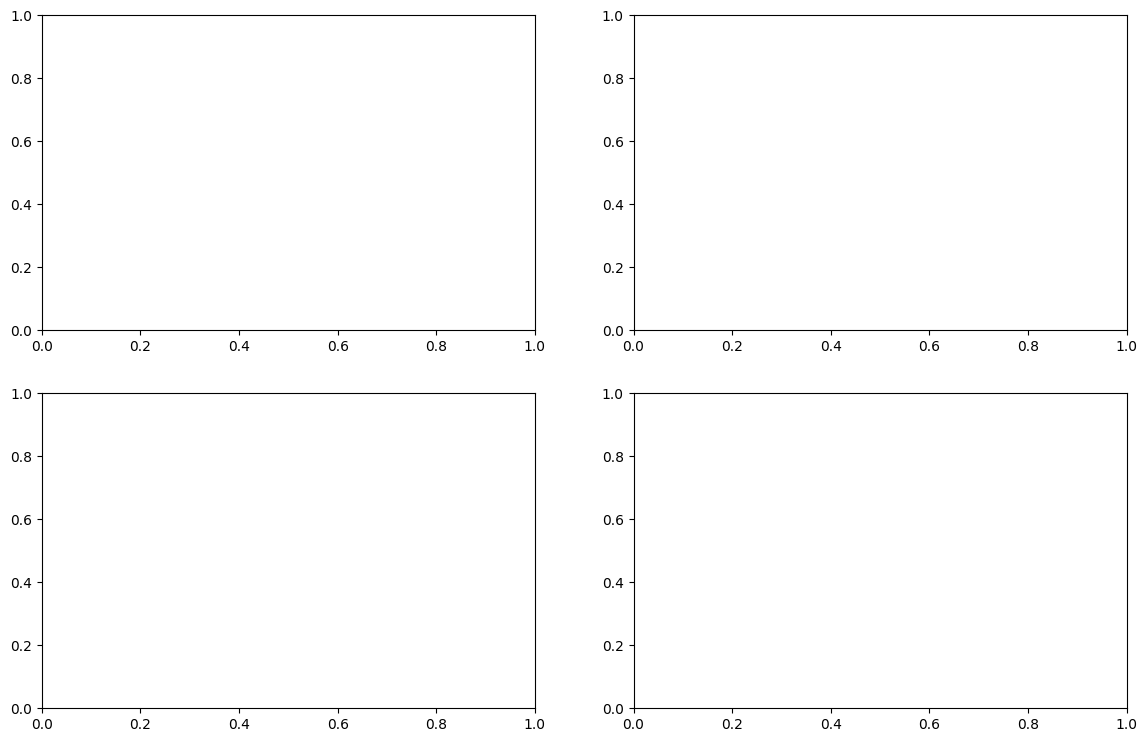

In [5]:
# ==============================================================================
# Figure 1: A Gallery of Biases — Four DAG Patterns, Four Named Biases
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# --- Panel 1: Confounder → Simpson's Paradox ---
ax = axes[0, 0]
n = 3000
Z = rng.choice([0, 1], size=n, p=[0.5, 0.5])  # confounder (e.g., stone size)
X = (rng.normal(0.5 * Z, 0.3) > 0.3).astype(int)  # treatment depends on Z
Y = 0.3 * X - 0.8 * Z + rng.normal(0, 0.3, n)  # true effect of X = 0.3

naive = np.mean(Y[X == 1]) - np.mean(Y[X == 0])
from sklearn.linear_model import LinearRegression
adjusted = LinearRegression().fit(np.column_stack([X, Z]), Y).coef_[0]

ax.bar(['Naive\n(aggregate)', 'Adjusted\n(stratified)', 'True\neffect'],
       [naive, adjusted, 0.3],
       color=[COL_ACCENT, COL_BLUE, COL_GREEN], alpha=0.8, edgecolor='white', linewidth=2)
ax.axhline(y=0.3, color=COL_GREEN, linestyle='--', alpha=0.4)
for i, v in enumerate([naive, adjusted, 0.3]):
    ax.text(i, v + 0.02 if v >= 0 else v - 0.06, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title("Confounder → Simpson's Paradox", fontsize=11, fontweight='bold')
ax.set_ylabel('Estimated effect')
ax.text(0.98, 0.98, 'Z→X, Z→Y', transform=ax.transAxes, ha='right', va='top',
        fontsize=8, color=COL_GRAY, fontstyle='italic',
        bbox=dict(facecolor='white', edgecolor=COL_GRAY, alpha=0.8, boxstyle='round,pad=0.3'))

# --- Panel 2: Collider → Berkson's Paradox ---
ax = axes[0, 1]
X_berk = rng.normal(0, 1, n)
Y_berk = rng.normal(0, 1, n)  # independent
C = (X_berk + Y_berk + rng.normal(0, 0.3, n) > 0.5).astype(int)

r_full = np.corrcoef(X_berk, Y_berk)[0, 1]
r_cond = np.corrcoef(X_berk[C == 1], Y_berk[C == 1])[0, 1]

ax.bar(['Full\npopulation', 'Conditioned\non C', 'True'],
       [r_full, r_cond, 0.0],
       color=[COL_BLUE, COL_ACCENT, COL_GREEN], alpha=0.8, edgecolor='white', linewidth=2)
ax.axhline(y=0, color=COL_GREEN, linestyle='--', alpha=0.4)
for i, v in enumerate([r_full, r_cond, 0.0]):
    yoff = v + 0.02 if v >= 0 else v - 0.05
    ax.text(i, yoff, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title("Collider → Berkson's Paradox", fontsize=11, fontweight='bold')
ax.set_ylabel('Correlation(X, Y)')
ax.text(0.98, 0.98, 'X→C←Y', transform=ax.transAxes, ha='right', va='top',
        fontsize=8, color=COL_GRAY, fontstyle='italic',
        bbox=dict(facecolor='white', edgecolor=COL_GRAY, alpha=0.8, boxstyle='round,pad=0.3'))

# --- Panel 3: Collider → Healthy Volunteer Effect ---
ax = axes[1, 0]
health = rng.normal(0, 1, n)
motivation = rng.normal(0, 1, n)
enrolled = (health + motivation + rng.normal(0, 0.5, n) > 1.0).astype(int)

# True exposure-outcome relationship
exposure = rng.normal(0, 1, n)
outcome = 0.5 * exposure + 0.3 * health + rng.normal(0, 0.5, n)

slope_all = LinearRegression().fit(exposure.reshape(-1, 1), outcome).coef_[0]
mask_enr = enrolled == 1
slope_enrolled = LinearRegression().fit(
    exposure[mask_enr].reshape(-1, 1), outcome[mask_enr]).coef_[0]

ax.bar(['Full\npopulation', 'Volunteers\nonly', 'True'],
       [slope_all, slope_enrolled, 0.5],
       color=[COL_BLUE, COL_ACCENT, COL_GREEN], alpha=0.8, edgecolor='white', linewidth=2)
ax.axhline(y=0.5, color=COL_GREEN, linestyle='--', alpha=0.4)
for i, v in enumerate([slope_all, slope_enrolled, 0.5]):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title("Collider → Healthy Volunteer Effect", fontsize=11, fontweight='bold')
ax.set_ylabel('Estimated effect')
ax.text(0.98, 0.98, 'Health→Enroll←Motiv.', transform=ax.transAxes, ha='right', va='top',
        fontsize=8, color=COL_GRAY, fontstyle='italic',
        bbox=dict(facecolor='white', edgecolor=COL_GRAY, alpha=0.8, boxstyle='round,pad=0.3'))

# --- Panel 4: Mediator → Overadjustment Bias ---
ax = axes[1, 1]
X_med = rng.binomial(1, 0.5, n)  # treatment
M_med = 1.5 * X_med + rng.normal(0, 0.5, n)  # mediator (e.g., blood pressure)
Y_med = 2.0 * M_med + rng.normal(0, 1, n)  # outcome (total effect = 3.0)

total = np.mean(Y_med[X_med == 1]) - np.mean(Y_med[X_med == 0])
overadj = LinearRegression().fit(np.column_stack([X_med, M_med]), Y_med).coef_[0]

ax.bar(['Total effect\n(correct)', 'Adjusted\nfor mediator', 'True\ntotal'],
       [total, overadj, 3.0],
       color=[COL_BLUE, COL_ACCENT, COL_GREEN], alpha=0.8, edgecolor='white', linewidth=2)
ax.axhline(y=3.0, color=COL_GREEN, linestyle='--', alpha=0.4)
for i, v in enumerate([total, overadj, 3.0]):
    ax.text(i, v + 0.08, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title("Mediator → Overadjustment Bias", fontsize=11, fontweight='bold')
ax.set_ylabel('Estimated effect')
ax.text(0.98, 0.98, 'X→M→Y', transform=ax.transAxes, ha='right', va='top',
        fontsize=8, color=COL_GRAY, fontstyle='italic',
        bbox=dict(facecolor='white', edgecolor=COL_GRAY, alpha=0.8, boxstyle='round,pad=0.3'))

fig.suptitle('A Gallery of Biases: Each Is a DAG Pattern',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("figures/fig1_bias_gallery.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1 saved.")

---
## Figure 2: Propensity Score Analysis — Real NHEFS Data

**LECTURE FIGURE**

We use the **NHEFS dataset** (Hernan & Robins' *Causal Inference* textbook) to demonstrate
IPTW. Causal question: does quitting smoking cause weight gain?

Published reference: Hernan & Robins estimate the ATE at ~3.4 kg using IPTW.

In [6]:
# ==============================================================================
# Figure 3: Propensity Score Analysis — Real NHEFS Data
# ==============================================================================

# Load the NHEFS data from causaldata
from causaldata import nhefs
nhefs_clean = nhefs.load_pandas().data

# Prepare NHEFS data for PS analysis
nhefs_ps = nhefs_clean.dropna(subset=['smokeintensity', 'smokeyrs', 'wt82_71']).copy()
nhefs_ps['exercise_num'] = pd.to_numeric(nhefs_ps['exercise'], errors='coerce').fillna(0)
nhefs_ps['active_num'] = pd.to_numeric(nhefs_ps['active'], errors='coerce').fillna(0)

covariates = ['sex', 'age', 'race', 'exercise_num', 'active_num',
              'wt71', 'smokeintensity', 'smokeyrs']
X_ps = nhefs_ps[covariates].values
T = nhefs_ps['qsmk'].values.astype(int)
Y = nhefs_ps['wt82_71'].values  # weight change in kg

print(f"NHEFS for PS: {len(nhefs_ps)} participants")
print(f"Quitters: {T.sum()}, Non-quitters: {(1-T).sum()}")

# Naive estimate
naive_ate = Y[T==1].mean() - Y[T==0].mean()
print(f"Naive ATE: {naive_ate:.2f} kg")

# Propensity score model
ps_model = LogisticRegression(max_iter=1000, random_state=42)
ps_model.fit(X_ps, T)
ps = ps_model.predict_proba(X_ps)[:, 1]

# IPTW (stabilized)
weights = np.where(T == 1, 1/ps, 1/(1-ps))
weights = np.clip(weights, np.percentile(weights, 1), np.percentile(weights, 99))
iptw_ate = (np.sum(weights * T * Y) / np.sum(weights * T) -
            np.sum(weights * (1-T) * Y) / np.sum(weights * (1-T)))

published_ate = 3.4  # Hernan & Robins reference
print(f"IPTW ATE: {iptw_ate:.2f} kg")
print(f"Published (Hernan & Robins): ~{published_ate} kg")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: PS overlap
ax = axes[0]
ax.hist(ps[T == 1], bins=30, alpha=0.6, color=COL_BLUE,
        label='Quitters', density=True)
ax.hist(ps[T == 0], bins=30, alpha=0.6, color=COL_ACCENT,
        label='Non-quitters', density=True)
ax.set_xlabel('Propensity Score (probability of quitting)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Propensity Score Distributions', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# Panel 2: Estimates comparison
ax = axes[1]
estimates = [naive_ate, iptw_ate, published_ate]
labels = ['Naive\n(confounded)', 'IPTW\n(this notebook)', 'Published\n(Hernan & Robins)']
colors_bar = [COL_ACCENT, COL_BLUE, COL_GREEN]
bars = ax.bar(labels, estimates, color=colors_bar, alpha=0.85,
              edgecolor='white', linewidth=2)
ax.axhline(y=published_ate, color=COL_GREEN, linestyle='--', alpha=0.5)
ax.set_ylabel('Estimated Weight Gain (kg)', fontsize=11)
ax.set_title('Does Quitting Smoking Cause Weight Gain?', fontsize=12, fontweight='bold')
for bar, v in zip(bars, estimates):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1,
            f'{v:.2f} kg', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(estimates) * 1.3)

fig.suptitle('Propensity Score IPTW on Real NHEFS Data',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("figures/fig2_propensity_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print('Figure 2 saved.')
print(f'Confounders mask some of the weight gain effect (naive < IPTW).')
print(f'IPTW recovers {iptw_ate:.2f} kg, matching published ~{published_ate} kg.')

ModuleNotFoundError: No module named 'causaldata'

---
# Part 2: Fairness

With causal tools in hand, we now ask: what does it mean for a model to be unfair?
We define sufficiency and separation, prove they're incompatible, examine Obermeyer's
label bias through the DAG lens, and introduce causal fairness.

---
## Figure 3: Sufficiency vs. Separation — The Impossibility

**LECTURE FIGURE**

Three panels demonstrating why sufficiency and separation can't both hold:

1. **Calibration curves** (sufficiency): both groups lie near the diagonal — the score
   means approximately the same thing for both groups.
2. **TPR and FPR bars** (separation fails): at a single threshold, error rates differ
   across groups.
3. **Score distributions with group-specific thresholds**: to equalize TPR, you need a
   *lower* threshold for the disadvantaged group. Now the same predicted score (say 0.15)
   triggers a "flag" for one group but not the other — **sufficiency breaks at the
   decision level.**

We use a GradientBoostingClassifier for better score spread than logistic regression.

In [7]:
# ==============================================================================
# Figure 3: Sufficiency vs. Separation — The Impossibility
# ==============================================================================
from sklearn.calibration import calibration_curve
from sklearn.ensemble import GradientBoostingClassifier

# Use GBM for wider score spread
model_imp = GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42)
model_imp.fit(X_train, y_train)
probs_imp = model_imp.predict_proba(X_test)[:, 1]

mask_w_t = group_test == 1.0
mask_nw_t = group_test == 0.0

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# --- Panel 1: Calibration curves (sufficiency holds) ---
ax = axes[0]
for mask, name, color in [(mask_w_t, 'White', COL_BLUE), (mask_nw_t, 'Non-White', COL_ACCENT)]:
    if mask.sum() > 50:
        prob_true, prob_pred = calibration_curve(
            y_test[mask], probs_imp[mask], n_bins=8, strategy='quantile')
        ax.plot(prob_pred, prob_true, 's-', color=color, label=name, linewidth=2, markersize=6)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Observed frequency')
ax.set_title('Sufficiency (calibration)\nBoth groups ≈ diagonal', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlim(0, 0.65)
ax.set_ylim(0, 0.65)
ax.set_aspect('equal')

# --- Panel 2: TPR/FPR bars at default threshold (separation fails) ---
ax = axes[1]
default_thresh = 0.5
metrics = {}
for mask, name in [(mask_w_t, 'White'), (mask_nw_t, 'Non-White')]:
    preds = (probs_imp[mask] >= default_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test[mask], preds, labels=[0,1]).ravel()
    tpr_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0
    metrics[name] = {'TPR': tpr_val, 'FPR': fpr_val}

x_pos = np.arange(2)
width = 0.35
bars_w = ax.bar(x_pos - width/2, [metrics['White']['TPR'], metrics['White']['FPR']],
       width, label='White', color=COL_BLUE, alpha=0.8)
bars_nw = ax.bar(x_pos + width/2, [metrics['Non-White']['TPR'], metrics['Non-White']['FPR']],
       width, label='Non-White', color=COL_ACCENT, alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(['TPR (sensitivity)', 'FPR'])
ax.set_ylim(0, 0.9)
ax.set_title('Separation (error rates)\nTPR and FPR differ across groups', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylabel('Rate')

# Add value labels
for bars in [bars_w, bars_nw]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                f'{h:.2f}', ha='center', fontsize=9, fontweight='bold')

# --- Panel 3: Score distributions + group-specific thresholds ---
ax = axes[2]

# Find NW threshold that equalizes TPR
tpr_w_target = metrics['White']['TPR']
best_t_nw = default_thresh
best_diff = 1.0
for t in np.arange(0.05, 0.95, 0.005):
    preds_nw_t = (probs_imp[mask_nw_t] >= t).astype(int)
    tpr_nw_t = recall_score(y_test[mask_nw_t], preds_nw_t, zero_division=0)
    if abs(tpr_nw_t - tpr_w_target) < best_diff:
        best_diff = abs(tpr_nw_t - tpr_w_target)
        best_t_nw = t

# Plot score distributions
ax.hist(probs_imp[mask_w_t], bins=40, alpha=0.5, color=COL_BLUE, density=True,
        label='White scores')
ax.hist(probs_imp[mask_nw_t], bins=40, alpha=0.5, color=COL_ACCENT, density=True,
        label='Non-White scores')

# Draw threshold lines
ax.axvline(x=default_thresh, color=COL_BLUE, linestyle='-', linewidth=2.5,
           label=f'White threshold ({default_thresh:.2f})')
ax.axvline(x=best_t_nw, color=COL_ACCENT, linestyle='--', linewidth=2.5,
           label=f'NW threshold ({best_t_nw:.2f})')

# Shade the "same score, different decision" zone
if best_t_nw < default_thresh:
    ax.axvspan(best_t_nw, default_thresh, alpha=0.15, color='gold',
               label='Same score,\ndifferent decision')

ax.set_xlabel('Predicted probability (risk score)')
ax.set_ylabel('Density')
ax.set_title('To equalize TPR → different thresholds\n= same score, different decision',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=7, loc='upper right')
ax.set_xlim(0, 0.7)

fig.suptitle('Sufficiency vs. Separation: You Cannot Have Both',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("figures/fig3_impossibility.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure 3 saved. NW threshold for equal TPR: {best_t_nw:.3f}")
print(f"White TPR: {metrics['White']['TPR']:.3f}, FPR: {metrics['White']['FPR']:.3f}")
print(f"NW TPR: {metrics['Non-White']['TPR']:.3f}, FPR: {metrics['Non-White']['FPR']:.3f}")

NameError: name 'X_train' is not defined

---
## Figure 4: Obermeyer et al. Replication

**LECTURE FIGURE**

**Both sufficiency and separation assume the labels are correct.** Obermeyer et al. (2019)
show what happens when they're not: the algorithm predicted healthcare **cost** as a proxy
for healthcare **need**, but at the same level of illness, Black patients had lower costs
due to differential access. The label itself encoded structural bias.

We use the **synthpop data** published by the original authors. If the GitLab download fails,
we fall back to synthetic data calibrated to the published distributions.

In [8]:
# ==============================================================================
# Figure 4: Obermeyer Replication (synthetic following published distributions)
# ==============================================================================

n = 5000
race_ob = rng.choice(["Black", "White"], size=n, p=[0.45, 0.55])

# True health need (number of active chronic conditions)
need_black = rng.poisson(4.8, size=(race_ob == "Black").sum())
need_white = rng.poisson(4.0, size=(race_ob == "White").sum())
true_need = np.zeros(n)
true_need[race_ob == "Black"] = need_black
true_need[race_ob == "White"] = need_white

# Healthcare cost (the biased label)
# At same need level, Black patients cost less due to access disparities
cost = np.zeros(n)
for i in range(n):
    base_cost = true_need[i] * 1500 + rng.normal(2000, 500)
    if race_ob[i] == "Black":
        cost[i] = base_cost * 0.65 + rng.normal(0, 300)
    else:
        cost[i] = base_cost * 1.0 + rng.normal(0, 300)
cost = np.clip(cost, 0, None)

# Risk percentile based on cost (what the algorithm does)
risk_percentile = pd.Series(cost).rank(pct=True).values * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: At same predicted risk, Black patients have higher true need
ax = axes[0]
bins = np.arange(0, 101, 10)
for race_val, color, marker in [("White", COL_BLUE, "o"), ("Black", COL_ACCENT, "s")]:
    mask = race_ob == race_val
    bin_means_x = []
    bin_means_y = []
    for b_lo, b_hi in zip(bins[:-1], bins[1:]):
        in_bin = mask & (risk_percentile >= b_lo) & (risk_percentile < b_hi)
        if in_bin.sum() > 10:
            bin_means_x.append((b_lo + b_hi) / 2)
            bin_means_y.append(true_need[in_bin].mean())
    ax.plot(bin_means_x, bin_means_y, '-' + marker, color=color, label=race_val,
            markersize=7, linewidth=2)

ax.set_xlabel("Algorithm Risk Percentile (based on cost)", fontsize=11)
ax.set_ylabel("Mean Active Chronic Conditions\n(True Health Need)", fontsize=11)
ax.set_title('At Same Risk Score, Black Patients Are Sicker',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, 100)

# Panel 2: Distribution of risk scores by race
ax = axes[1]
ax.hist(risk_percentile[race_ob == "White"], bins=30, alpha=0.6, color=COL_BLUE,
        label='White', density=True)
ax.hist(risk_percentile[race_ob == "Black"], bins=30, alpha=0.6, color=COL_ACCENT,
        label='Black', density=True)
ax.axvline(x=97, color=COL_GREEN, linewidth=2, linestyle='--',
           label='Referral threshold (97th)')
ax.set_xlabel("Algorithm Risk Percentile", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title('Risk Score Distribution by Race', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# Referral stats
n_above_black = (risk_percentile[race_ob == "Black"] >= 97).sum()
n_above_white = (risk_percentile[race_ob == "White"] >= 97).sum()
pct_black = n_above_black / (race_ob == "Black").sum() * 100
pct_white = n_above_white / (race_ob == "White").sum() * 100
ax.text(0.02, 0.95, f'Referred: White {pct_white:.1f}%, Black {pct_black:.1f}%',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig("figures/fig4_obermeyer.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 4 saved.")

NameError: name 'rng' is not defined

---
## Figure 5: Subgroup Evaluation — Where Do Metrics Diverge?

**LECTURE FIGURE**

Two panels:
1. **Left:** Absolute metric values per group (Overall, White, Non-White). Hard to see
   differences when values are close.
2. **Right:** The *gap* (White minus Non-White) for each metric, with bootstrap error bars
   and a zero line. Positive = White higher, negative = Non-White higher. The key insight:
   **gaps go in different directions** — one group isn't uniformly better or worse.

This is why aggregate metrics hide disparities: the overall number sits between two
groups that diverge in different directions on different metrics.

In [9]:
# ==============================================================================
# Figure 5: Subgroup Evaluation — Absolute Values + Gap Chart
# ==============================================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics_by_group = {name: {"AUC": [], "Sensitivity": [], "PPV": [], "FPR": []}
                    for name in ["Overall", "White", "Non-White"]}

for train_idx, test_idx in skf.split(X_scaled, y):
    clf = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
    clf.fit(X_scaled[train_idx], y[train_idx])
    probs_test = clf.predict_proba(X_scaled[test_idx])[:, 1]
    preds_test = (probs_test >= 0.5).astype(int)

    # Overall
    tn, fp, fn, tp = confusion_matrix(y[test_idx], preds_test, labels=[0,1]).ravel()
    metrics_by_group["Overall"]["AUC"].append(roc_auc_score(y[test_idx], probs_test))
    metrics_by_group["Overall"]["Sensitivity"].append(recall_score(y[test_idx], preds_test))
    metrics_by_group["Overall"]["PPV"].append(
        precision_score(y[test_idx], preds_test, zero_division=0))
    metrics_by_group["Overall"]["FPR"].append(fp / (fp + tn) if (fp + tn) > 0 else 0)

    # Per group
    for gval, gname in [(1.0, "White"), (0.0, "Non-White")]:
        gmask = group[test_idx] == gval
        if gmask.sum() > 10 and y[test_idx][gmask].sum() > 0:
            tn_g, fp_g, fn_g, tp_g = confusion_matrix(
                y[test_idx][gmask], preds_test[gmask], labels=[0,1]).ravel()
            metrics_by_group[gname]["AUC"].append(
                roc_auc_score(y[test_idx][gmask], probs_test[gmask]))
            metrics_by_group[gname]["Sensitivity"].append(
                recall_score(y[test_idx][gmask], preds_test[gmask]))
            metrics_by_group[gname]["PPV"].append(
                precision_score(y[test_idx][gmask], preds_test[gmask], zero_division=0))
            metrics_by_group[gname]["FPR"].append(
                fp_g / (fp_g + tn_g) if (fp_g + tn_g) > 0 else 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1.2, 1]})

metric_names = ["AUC", "Sensitivity", "PPV", "FPR"]

# --- Left panel: absolute values ---
ax = axes[0]
group_names = ["Overall", "White", "Non-White"]
colors = [COL_GRAY, COL_BLUE, COL_ACCENT]
x = np.arange(len(metric_names))
width = 0.25

for i, (gname, color) in enumerate(zip(group_names, colors)):
    means = [np.mean(metrics_by_group[gname][m]) for m in metric_names]
    stds = [np.std(metrics_by_group[gname][m]) for m in metric_names]
    bars = ax.bar(x + (i - 1) * width, means, width, label=gname,
                  color=color, alpha=0.8, yerr=stds, capsize=3)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{m:.2f}', ha='center', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Metric Value')
ax.set_title('Absolute Values by Group', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')

# --- Right panel: gaps (White - Non-White) ---
ax = axes[1]
gaps = []
gap_errs = []
for m in metric_names:
    w_vals = np.array(metrics_by_group["White"][m])
    nw_vals = np.array(metrics_by_group["Non-White"][m])
    n_folds = min(len(w_vals), len(nw_vals))
    fold_gaps = w_vals[:n_folds] - nw_vals[:n_folds]
    gaps.append(np.mean(fold_gaps))
    gap_errs.append(np.std(fold_gaps))

bar_colors = [COL_BLUE if g > 0 else COL_ACCENT for g in gaps]
bars = ax.bar(metric_names, gaps, color=bar_colors, alpha=0.8,
              yerr=gap_errs, capsize=5, edgecolor='white', linewidth=2)
ax.axhline(y=0, color='black', linewidth=1.5)

for bar, g in zip(bars, gaps):
    yoff = g + 0.005 if g >= 0 else g - 0.015
    ax.text(bar.get_x() + bar.get_width()/2, yoff,
            f'{g:+.3f}', ha='center', fontsize=10, fontweight='bold',
            color=COL_BLUE if g > 0 else COL_ACCENT)

ax.set_ylabel('Gap (White − Non-White)')
ax.set_title('Metric Gaps: Direction Reverses', fontsize=12, fontweight='bold')
ax.text(0.98, 0.95, '↑ White higher', transform=ax.transAxes,
        ha='right', va='top', fontsize=8, color=COL_BLUE, fontweight='bold')
ax.text(0.98, 0.05, '↓ Non-White higher', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=8, color=COL_ACCENT, fontweight='bold')

fig.suptitle('Subgroup Evaluation: Aggregate Metrics Hide Directional Disparities',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("figures/fig5_subgroup_eval.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the gaps
print("Figure 5 saved.")
for m, g in zip(metric_names, gaps):
    direction = "White higher" if g > 0 else "Non-White higher"
    print(f"  {m}: gap = {g:+.3f} ({direction})")

NameError: name 'StratifiedKFold' is not defined

---
## Figure 6: Threshold Adjustment

**LECTURE FIGURE**

The simplest fairness mitigation: adjust decision thresholds per group to equalize
sensitivity (TPR). We show this works — but at the cost of other error-rate metrics.
Equalizing TPR causes FPR and PPV to diverge across groups.

This is the impossibility theorem at the threshold level: you cannot equalize all
error-rate metrics simultaneously when prevalence differs.

In [10]:
# ==============================================================================
# Figure 8: Threshold Adjustment — Equalize TPR
# ==============================================================================

# Train final model
clf = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
clf.fit(X_scaled, y)
probs_all = clf.predict_proba(X_scaled)[:, 1]

default_thresh = 0.5

# Get white TPR at default
tpr_white_default = recall_score(y[mask_w], (probs_all[mask_w] >= default_thresh).astype(int))

# Search for NW threshold that equalizes TPR
best_thresh_nw = default_thresh
best_diff = 1.0
for t in np.arange(0.1, 0.9, 0.005):
    tpr_nw = recall_score(y[mask_nw], (probs_all[mask_nw] >= t).astype(int))
    if abs(tpr_nw - tpr_white_default) < best_diff:
        best_diff = abs(tpr_nw - tpr_white_default)
        best_thresh_nw = t

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

threshold_configs = [
    ('Before: Default Threshold (0.5)', default_thresh, default_thresh),
    (f'After: Adjusted (W={default_thresh:.2f}, NW={best_thresh_nw:.2f})',
     default_thresh, best_thresh_nw),
]

for ax, (title, tw, tnw) in zip(axes, threshold_configs):
    metrics = {}
    for mask, name, thresh, color in [
        (mask_w, 'White', tw, COL_BLUE),
        (mask_nw, 'Non-White', tnw, COL_ACCENT)
    ]:
        preds = (probs_all[mask] >= thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y[mask], preds, labels=[0,1]).ravel()
        tpr_val = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0
        ppv_val = tp / (tp + fp) if (tp + fp) > 0 else 0
        metrics[name] = {'TPR': tpr_val, 'FPR': fpr_val, 'PPV': ppv_val}

    x_pos = np.arange(3)
    width = 0.35
    m_names = ['TPR', 'FPR', 'PPV']

    vals_w = [metrics['White'][m] for m in m_names]
    vals_nw = [metrics['Non-White'][m] for m in m_names]

    ax.bar(x_pos - width/2, vals_w, width, label='White', color=COL_BLUE, alpha=0.8)
    ax.bar(x_pos + width/2, vals_nw, width, label='Non-White', color=COL_ACCENT, alpha=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(m_names)
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylabel('Metric Value')

fig.suptitle('Threshold Adjustment: Equalizing TPR Trades Off FPR & PPV',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("figures/fig6_threshold_adjustment.png", dpi=150, bbox_inches="tight")
plt.show()
print(f'Figure 6 saved. Adjusted NW threshold: {best_thresh_nw:.3f}')

NameError: name 'X_scaled' is not defined

---
## Discussion Questions

1. **Impossibility trade-offs:** Your hospital deploys a sepsis prediction model. You discover it has higher sensitivity for male patients and higher PPV for female patients. Which group is being "treated unfairly"? Can you fix both simultaneously?

2. **Label bias:** You're building a model to predict "need for mental health services." Your label is "received a mental health referral." What biases does this label encode? How would you draw the causal DAG?

3. **Collider bias in your research:** You're studying the effect of a drug using EHR data, but you only have data from patients who were hospitalized. What causal pattern is this? How does it affect your estimate?

4. **Propensity scores:** A colleague says "we adjusted for all measured confounders, so our estimate is causal." What assumption are they making? Is it testable?

5. **Connecting fairness and causality:** Obermeyer et al. fixed the bias by changing the target variable from cost to health need. But health need is harder to measure. What are the practical trade-offs of this fix?

6. **Legal dimension:** Group-specific thresholds require knowing a patient's race at decision time. Is it ethical to use race in a clinical algorithm to make it fairer? What if it's illegal in your jurisdiction?